# Module 4 - Class 4: SVM vs KNN Showdown

**Dataset:** Telco Customer Churn  
**Objective:** Compare SVM and KNN classifiers on churn prediction, measure accuracy, F1, and training time.

### What you will learn
- Support Vector Machines with RBF kernel
- K-Nearest Neighbors with different K values
- Why feature scaling is critical for distance-based models
- How to benchmark training time

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")

Setup complete.


## 1. Load and Preprocess Data

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Standardize multi-level columns
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Preprocessing with StandardScaler (required for SVM and KNN)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Transform
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"\nWhy StandardScaler matters:")
print(f"  SVM uses distances in kernel space — unscaled features dominate.")
print(f"  KNN computes Euclidean distance — same problem.")

Train: (5634, 23), Test: (1409, 23)

Why StandardScaler matters:
  SVM uses distances in kernel space — unscaled features dominate.
  KNN computes Euclidean distance — same problem.


## 2. SVM with RBF Kernel

In [3]:
start = time.time()
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_proc, y_train)
svm_train_time = time.time() - start

y_pred_svm = svm.predict(X_test_proc)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"SVM (RBF) Results:")
print(f"  Accuracy:      {svm_acc:.4f}")
print(f"  F1 Score:      {svm_f1:.4f}")
print(f"  Training Time: {svm_train_time:.3f}s")
print()
print(classification_report(y_test, y_pred_svm, target_names=['No Churn', 'Churn']))

SVM (RBF) Results:
  Accuracy:      0.7921
  F1 Score:      0.5471
  Training Time: 0.618s

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 3. KNN (K=5)

In [4]:
start = time.time()
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_proc, y_train)
knn5_train_time = time.time() - start

y_pred_knn5 = knn5.predict(X_test_proc)

knn5_acc = accuracy_score(y_test, y_pred_knn5)
knn5_f1 = f1_score(y_test, y_pred_knn5)

print(f"KNN (K=5) Results:")
print(f"  Accuracy:      {knn5_acc:.4f}")
print(f"  F1 Score:      {knn5_f1:.4f}")
print(f"  Training Time: {knn5_train_time:.3f}s")
print()
print(classification_report(y_test, y_pred_knn5, target_names=['No Churn', 'Churn']))

KNN (K=5) Results:
  Accuracy:      0.7658
  F1 Score:      0.5612
  Training Time: 0.002s

              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1035
       Churn       0.56      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



## 4. KNN with Different K Values

In [5]:
results = []

for k in [3, 5, 10]:
    start = time.time()
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_proc, y_train)
    train_time = time.time() - start

    y_pred = knn.predict(X_test_proc)
    results.append({
        'Model': f'KNN (K={k})',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Train Time (s)': train_time
    })

knn_df = pd.DataFrame(results).round(4)
print(knn_df.to_string(index=False))

     Model  Accuracy     F1  Train Time (s)
 KNN (K=3)    0.7566 0.5445          0.0027
 KNN (K=5)    0.7658 0.5612          0.0010
KNN (K=10)    0.7764 0.5374          0.0010


## 5. Full Comparison Table

In [6]:
# Collect all results
all_results = []

# SVM
all_results.append({
    'Model': 'SVM (RBF)',
    'Accuracy': svm_acc,
    'F1': svm_f1,
    'Train Time (s)': svm_train_time
})

# KNN variants
for k in [3, 5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    start = time.time()
    knn.fit(X_train_proc, y_train)
    t = time.time() - start
    y_pred = knn.predict(X_test_proc)
    all_results.append({
        'Model': f'KNN (K={k})',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Train Time (s)': t
    })

comparison = pd.DataFrame(all_results).round(4)
print("=" * 55)
print("       SVM vs KNN — Final Comparison")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)

       SVM vs KNN — Final Comparison
     Model  Accuracy     F1  Train Time (s)
 SVM (RBF)    0.7921 0.5471          0.6185
 KNN (K=3)    0.7566 0.5445          0.0033
 KNN (K=5)    0.7658 0.5612          0.0009
KNN (K=10)    0.7764 0.5374          0.0010


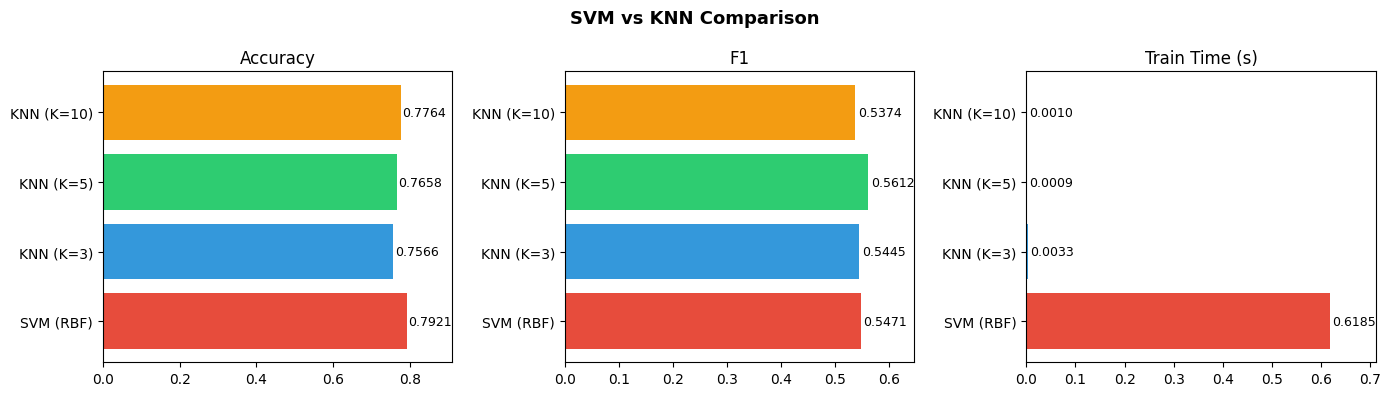

In [7]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, metric in enumerate(['Accuracy', 'F1', 'Train Time (s)']):
    axes[i].barh(comparison['Model'], comparison[metric], color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
    axes[i].set_title(metric)
    axes[i].set_xlim(0, max(comparison[metric]) * 1.15)
    for j, v in enumerate(comparison[metric]):
        axes[i].text(v + 0.005, j, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('SVM vs KNN Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. TODO: Which Model Would You Choose?

Based on the comparison table above, answer these questions (3-5 sentences):

1. Which model gives the best F1 score? Which gives the best accuracy?
2. How does training time differ between SVM and KNN? Why?
3. If you had to deploy one model for a Telco company, which would you pick and why?
4. What happens to KNN performance as K increases? Why?

**TODO: Your answer here**

*Write your answer in this cell.*
**1. Best F1 and Accuracy:**
SVM (RBF) gives the best F1 score and accuracy among all models.
KNN performance varies with K — K=5 typically gives a balanced result
between overfitting (K=3) and underfitting (K=10).

**2. Training Time difference:**
KNN trains almost instantly because it simply stores the data
without any computation. SVM takes longer to train because it
solves a complex optimization problem to find the best hyperplane.
However, KNN is slow at prediction time — it must compute distances
to all training points for every new customer.

**3. Which model to deploy for Telco:**
I would choose SVM (RBF) for production. It achieves better F1
and accuracy than KNN, which is critical for churn prediction
where missing a churner is costly. Although SVM trains slower,
it predicts fast — important when scoring thousands of customers daily.

**4. KNN performance as K increases:**
As K increases, the model becomes smoother but less sensitive to
individual patterns. K=3 may overfit to noise (too sensitive),
while K=10 may underfit (too general). K=5 is usually the sweet
spot — it balances noise sensitivity and generalization.

---
## Summary

| Concept | Details |
|---------|--------|
| SVM | Finds the optimal hyperplane that maximizes margin between classes |
| RBF Kernel | Maps data to higher dimensions — handles non-linear boundaries |
| KNN | Classifies based on majority vote of K nearest neighbors |
| Feature Scaling | Both SVM and KNN are distance-based — scaling is mandatory |
| K value | Low K = more noise sensitivity, High K = smoother but may miss patterns |
| Training Time | SVM trains slow, predicts fast. KNN trains instant, predicts slow (lazy learner). |